# Gold Layer: Clustering, Annotation & Differential Expression

This notebook transforms silver layer data into gold layer:
1. Load silver layer QC-normalized data
2. Leiden clustering to identify cell populations
3. CellTypist automated cell type annotation
4. Validate annotations with canonical brain marker genes
5. Differential expression: spaceflight vs ground control per cell type
6. Save annotated gold layer `.h5ad`

**Input:** `data/silver/osd352_brain_v1_qc.h5ad`

**Output:** `data/gold/osd352_brain_v1_annotated.h5ad`

## Step 1: Load Silver Layer

Load the QC-filtered, normalized AnnData from silver layer.
This already contains PCA and UMAP embeddings from the silver notebook.

In [2]:
# Standard library
from pathlib import Path

# Third-party
import numpy as np
import pandas as pd
import scanpy as sc
import celltypist
from celltypist import models
import matplotlib.pyplot as plt

# Load silver layer
adata = sc.read_h5ad('../data/silver/osd352_brain_v1_qc.h5ad')

print(f"Loaded: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Conditions: {adata.obs['condition'].value_counts().to_dict()}")
print(f"Embeddings: {list(adata.obsm.keys())}")

/Users/harry/miniforge3/envs/spaceGen/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


Loaded: 27968 cells × 32285 genes
Conditions: {'Space Flight': 17972, 'Ground Control': 9996}
Embeddings: ['X_pca', 'X_umap']


## Step 2: Leiden Clustering

Leiden algorithm identifies cell communities in the KNN graph (already computed in silver).
Resolution controls granularity — higher = more clusters.

We start with resolution=0.5 (moderate) and can adjust based on results.
Brain tissue typically has 10-20 major cell types.

In [3]:
# Leiden clustering at moderate resolution
# Resolution 0.5 typically gives 10-20 clusters for brain tissue
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_0.5')

n_clusters = adata.obs['leiden_0.5'].nunique()
print(f"Clusters found: {n_clusters}")
print(f"\nCells per cluster:")
print(adata.obs['leiden_0.5'].value_counts().sort_index())

Clusters found: 22

Cells per cluster:
leiden_0.5
0     11890
1      3293
2      2191
3      2080
4      1378
5       918
6       893
7       833
8       592
9       556
10      539
11      489
12      413
13      362
14      361
15      320
16      278
17      193
18      157
19      116
20       65
21       51
Name: count, dtype: int64


### Visualize clusters on UMAP

Check if clusters align with the structure we saw in the silver layer UMAP.
Also overlay condition to see which clusters are spaceflight-enriched.

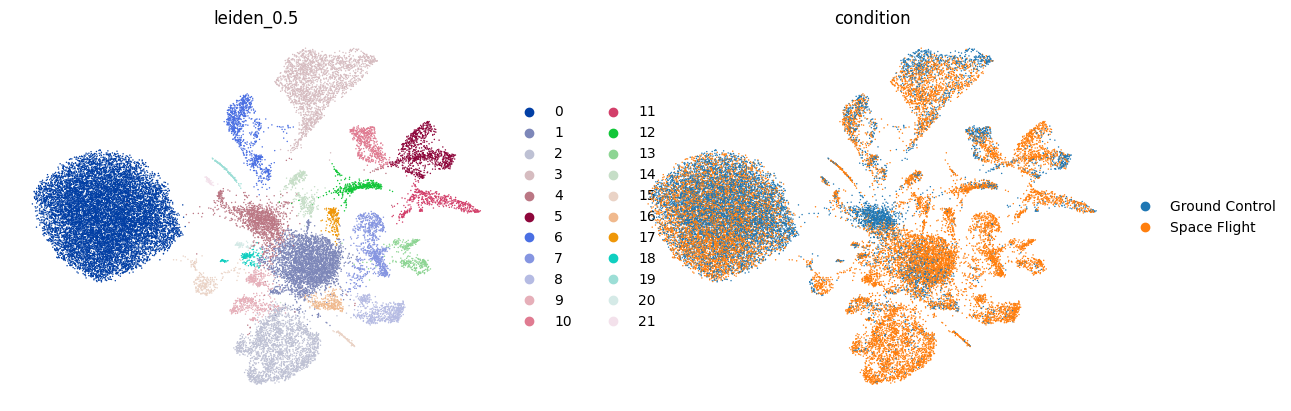

In [4]:
# UMAP colored by cluster and condition side-by-side
sc.pl.umap(adata, color=['leiden_0.5', 'condition'], ncols=2, frameon=False)

### Cluster composition by condition

Check which clusters are enriched in spaceflight vs ground control.
This reveals which cell populations are most affected by spaceflight.

Cluster composition (proportion by condition):
            Ground Control  Space Flight
leiden_0.5                              
7                    0.040         0.960
17                   0.047         0.953
13                   0.050         0.950
2                    0.050         0.950
8                    0.068         0.932
9                    0.126         0.874
14                   0.141         0.859
15                   0.169         0.831
11                   0.186         0.814
12                   0.186         0.814
1                    0.191         0.809
19                   0.198         0.802
5                    0.239         0.761
16                   0.263         0.737
18                   0.318         0.682
20                   0.323         0.677
3                    0.347         0.653
6                    0.410         0.590
10                   0.430         0.570
21                   0.451         0.549
0                    0.520         0.480
4         

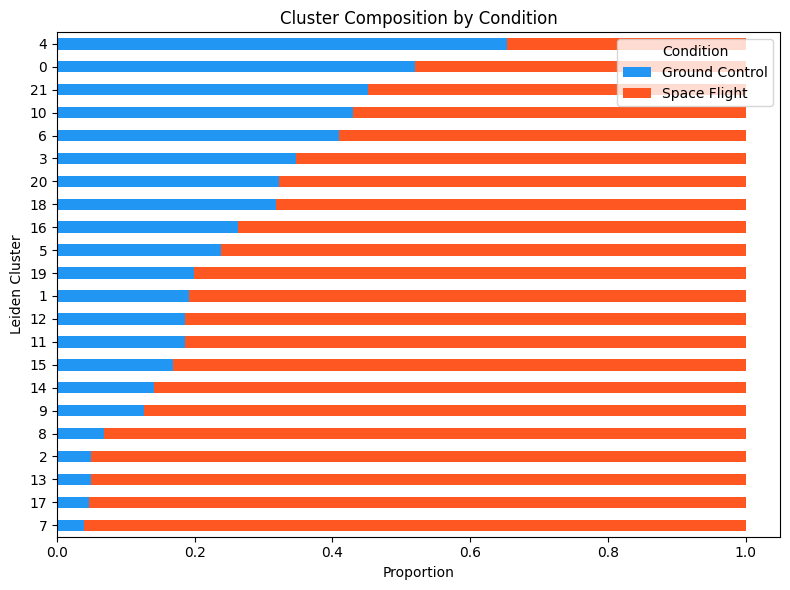

In [5]:
# Cross-tabulation: cluster × condition (as proportions)
ct = pd.crosstab(
    adata.obs['leiden_0.5'],
    adata.obs['condition'],
    normalize='index'  # proportion within each cluster
)
ct.columns = ['Ground Control', 'Space Flight']

# Sort by spaceflight enrichment
ct = ct.sort_values('Space Flight', ascending=False)

print("Cluster composition (proportion by condition):")
print(ct.round(3))

# Visualize as stacked bar chart
ct.plot(kind='barh', stacked=True, figsize=(8, 6), color=['#2196F3', '#FF5722'])
plt.xlabel('Proportion')
plt.ylabel('Leiden Cluster')
plt.title('Cluster Composition by Condition')
plt.legend(title='Condition')
plt.tight_layout()
plt.show()

## Step 3: CellTypist Automated Annotation

CellTypist uses pre-trained models to assign cell type labels.
We use a mouse brain model for initial annotation, then validate with markers.

CellTypist expects log-normalized data (which we have in `adata.X`).
It also needs the data to NOT be scaled — our X is log-normalized, not scaled, so we're good.

In [6]:
# Download and list available models
models.download_models(force_update=False)
available = models.models_description()

# Filter for mouse models
mouse_models = available[available['Species'].str.contains('Mouse', case=False, na=False)]
print(f"Available mouse models: {len(mouse_models)}")
print(mouse_models[['Model', 'Species', 'Tissue', 'No. cell types']].to_string())

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /Users/harry/.celltypist/data/models
💾 Downloading model [1/61]: Immune_All_Low.pkl
💾 Downloading model [2/61]: Immune_All_High.pkl
💾 Downloading model [3/61]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/61]: Adult_Human_MTG.pkl
💾 Downloading model [6/61]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/61]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/61]: Adult_Human_Skin.pkl
💾 Downloading model [9/61]: Adult_Human_Vascular.pkl
💾 Downloading model [10/61]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/61]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/61]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/61]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/61]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/61]: Adult_cHSPCs_Ultima.pkl
💾 Do

KeyError: 'Species'

### Run CellTypist prediction

Select the most appropriate mouse brain model and run prediction.
We use `majority_voting=True` to refine predictions using cluster-level consensus —
cells in the same Leiden cluster get the most common label, reducing noise.

In [7]:
# Load the mouse whole-brain model (best match for our data)
# If a specific brain model exists, we'll use that; otherwise fall back to general mouse
model = models.Model.load(model='Mouse_Whole_Brain.pkl')

# Run prediction with majority voting (uses leiden clusters for consensus)
predictions = celltypist.annotate(
    adata,
    model=model,
    majority_voting=True
)

# Transfer labels to our adata
adata = predictions.to_adata()

print(f"\nCell types found: {adata.obs['majority_voting'].nunique()}")
print(f"\nCell type distribution:")
print(adata.obs['majority_voting'].value_counts())

🔬 Input data has 27968 cells and 32285 genes
🔗 Matching reference genes in the model
🧬 5596 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!



Cell types found: 67

Cell type distribution:
majority_voting
314 CB Granule Glut              13305
327 Oligo NN                      2051
007 L2/3 IT CTX Glut               812
311 CBX MLI Megf11 Gaba            674
243 PGRN-PARN-MDRN Hoxb5 Glut      643
                                 ...  
228 PSV Pvalb Lhx2 Glut             37
050 Lamp5 Lhx6 Gaba                 32
023 SUB-ProS Glut                   29
313 CBX Purkinje Gaba               26
144 MM Foxb1 Glut                   26
Name: count, Length: 67, dtype: int64


### Visualize CellTypist annotations on UMAP

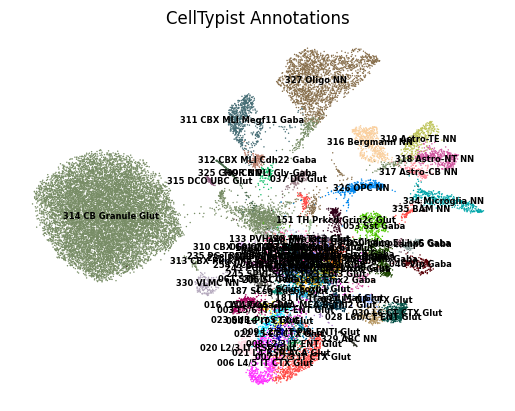

In [8]:
sc.pl.umap(adata, color='majority_voting', frameon=False, legend_loc='on data',
           legend_fontsize=6, title='CellTypist Annotations')

## Step 4: Validate with Canonical Brain Markers

Cross-check CellTypist labels against known marker genes for major brain cell types.
This is critical for credibility — shows we don't blindly trust automated tools.

**Key mouse brain markers:**
- Neurons: Rbfox3 (NeuN), Snap25, Syt1
- Excitatory neurons: Slc17a7 (Vglut1), Neurod6
- Inhibitory neurons: Gad1, Gad2, Slc32a1
- Astrocytes: Gfap, Aqp4, Aldh1l1
- Oligodendrocytes: Mbp, Plp1, Mog
- OPCs: Pdgfra, Cspg4
- Microglia: Cx3cr1, P2ry12, Tmem119
- Endothelial: Cldn5, Pecam1

In [9]:
# Define canonical brain cell type markers
marker_genes = {
    'Pan-neuronal': ['Rbfox3', 'Snap25', 'Syt1'],
    'Excitatory neurons': ['Slc17a7', 'Neurod6'],
    'Inhibitory neurons': ['Gad1', 'Gad2', 'Slc32a1'],
    'Astrocytes': ['Gfap', 'Aqp4', 'Aldh1l1'],
    'Oligodendrocytes': ['Mbp', 'Plp1', 'Mog'],
    'OPCs': ['Pdgfra', 'Cspg4'],
    'Microglia': ['Cx3cr1', 'P2ry12', 'Tmem119'],
    'Endothelial': ['Cldn5', 'Pecam1']
}

# Flatten to list, filter to genes present in our data
all_markers = [g for genes in marker_genes.values() for g in genes]
present_markers = [g for g in all_markers if g in adata.var_names]
missing_markers = [g for g in all_markers if g not in adata.var_names]

print(f"Markers present: {len(present_markers)}/{len(all_markers)}")
if missing_markers:
    print(f"Missing: {missing_markers}")

Markers present: 21/21


### Dotplot: marker expression by CellTypist annotation

Dotplot shows expression level (color) and fraction of cells expressing (dot size)
for each marker gene across cell types. If CellTypist labels are correct,
markers should light up in their expected cell types.

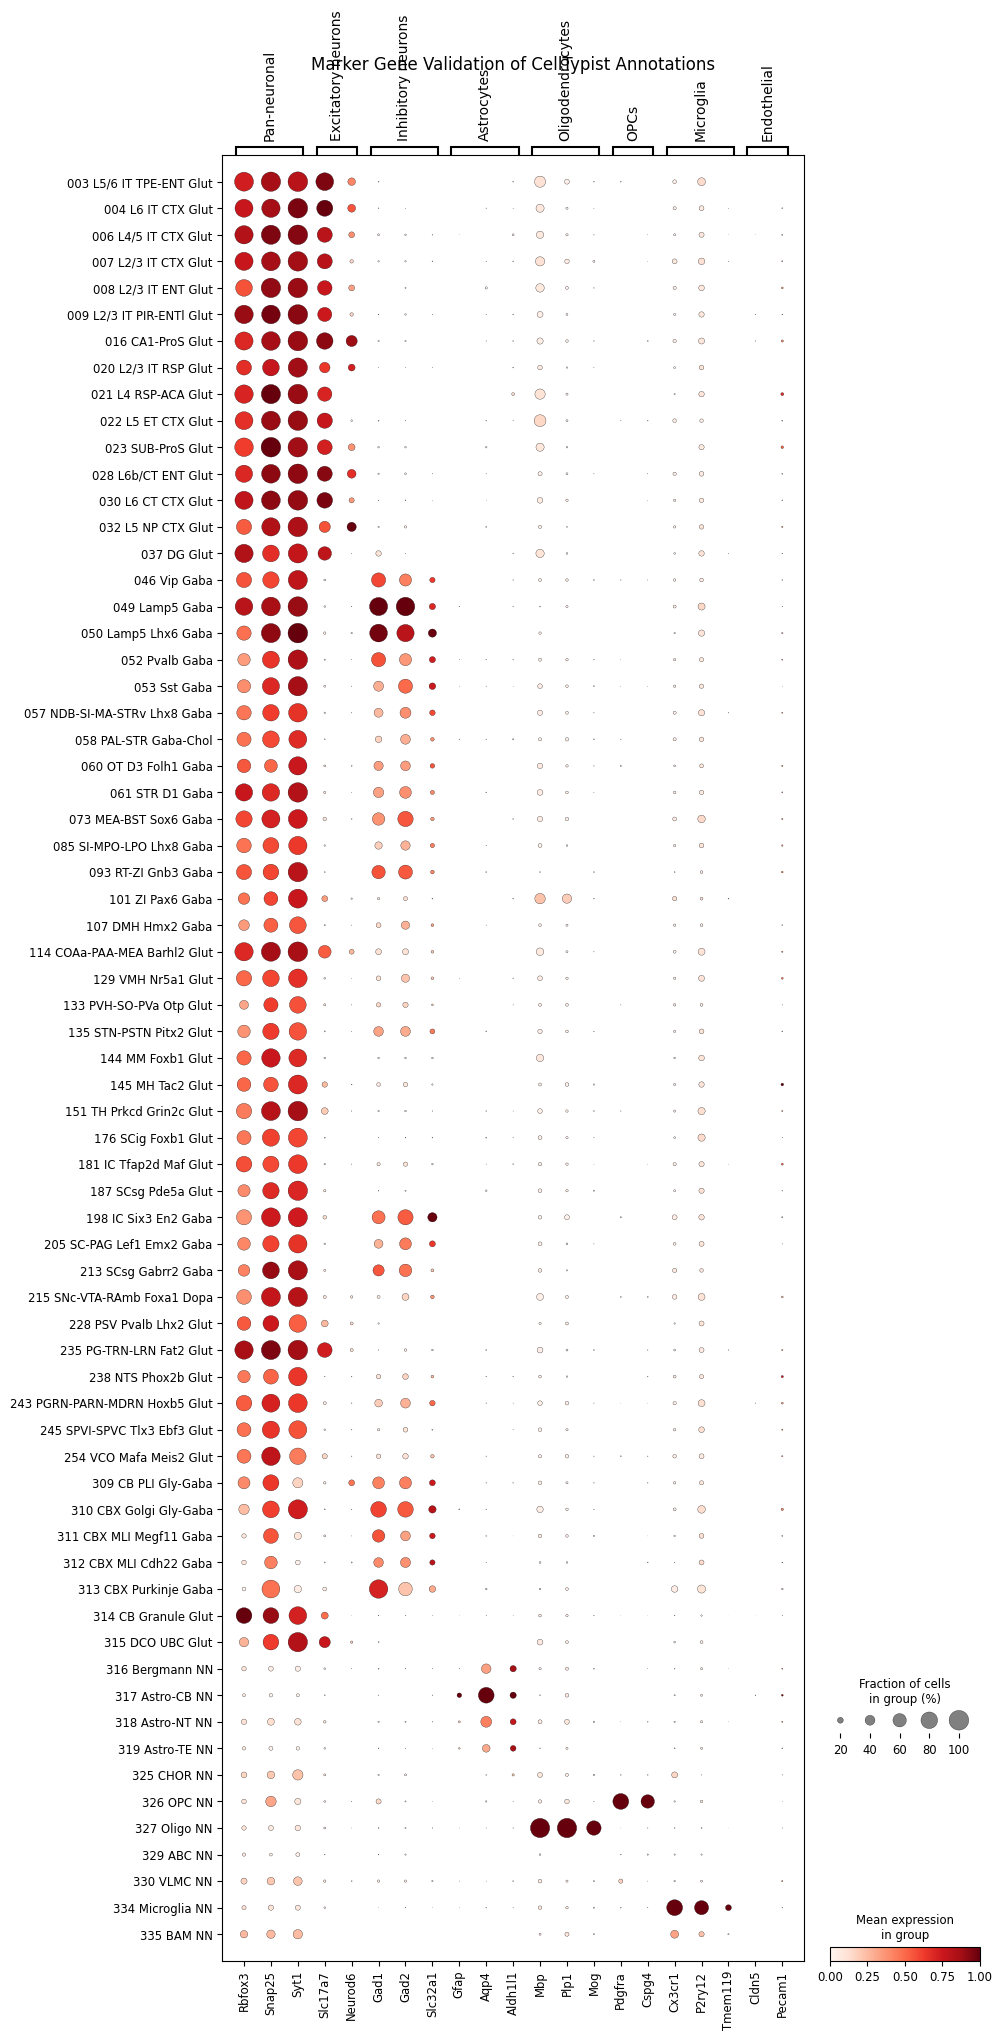

In [10]:
# Filter marker dict to only present genes
marker_genes_present = {
    k: [g for g in v if g in adata.var_names]
    for k, v in marker_genes.items()
}
# Remove empty categories
marker_genes_present = {k: v for k, v in marker_genes_present.items() if v}

sc.pl.dotplot(
    adata,
    var_names=marker_genes_present,
    groupby='majority_voting',
    standard_scale='var',
    title='Marker Gene Validation of CellTypist Annotations'
)

## Step 5: Differential Expression (Spaceflight vs Ground Control)

For each cell type, find genes that are differentially expressed between
spaceflight and ground control. This reveals cell-type-specific responses to spaceflight.

Using Wilcoxon rank-sum test (standard for scRNA-seq DE).
We test within each cell type to avoid confounding cell type differences with condition effects.

In [11]:
# Store cell type label in a clean column for DE
adata.obs['cell_type'] = adata.obs['majority_voting'].astype(str)

# Get cell types with enough cells in both conditions for meaningful DE
min_cells = 50  # minimum cells per condition per cell type

ct_counts = adata.obs.groupby(['cell_type', 'condition']).size().unstack(fill_value=0)
valid_types = ct_counts[(ct_counts >= min_cells).all(axis=1)].index.tolist()

print(f"Cell types with >= {min_cells} cells in both conditions: {len(valid_types)}")
for ct in valid_types:
    counts = ct_counts.loc[ct]
    print(f"  {ct}: GC={counts['Ground Control']}, Flight={counts['Space Flight']}")

Cell types with >= 50 cells in both conditions: 11
  181 IC Tfap2d Maf Glut: GC=104, Flight=355
  243 PGRN-PARN-MDRN Hoxb5 Glut: GC=214, Flight=429
  311 CBX MLI Megf11 Gaba: GC=276, Flight=398
  312 CBX MLI Cdh22 Gaba: GC=56, Flight=82
  314 CB Granule Glut: GC=7082, Flight=6223
  316 Bergmann NN: GC=224, Flight=293
  318 Astro-NT NN: GC=149, Flight=315
  326 OPC NN: GC=76, Flight=315
  327 Oligo NN: GC=696, Flight=1355
  330 VLMC NN: GC=51, Flight=191
  334 Microglia NN: GC=74, Flight=325


In [12]:
# Run DE for each valid cell type: spaceflight vs ground control
de_results = {}

for cell_type in valid_types:
    # Subset to this cell type
    mask = adata.obs['cell_type'] == cell_type
    adata_sub = adata[mask].copy()

    # Wilcoxon rank-sum test: Space Flight vs Ground Control
    sc.tl.rank_genes_groups(
        adata_sub,
        groupby='condition',
        groups=['Space Flight'],
        reference='Ground Control',
        method='wilcoxon',
        use_raw=True  # use raw counts for DE
    )

    # Extract results as dataframe
    result = sc.get.rank_genes_groups_df(adata_sub, group='Space Flight')
    result['cell_type'] = cell_type
    de_results[cell_type] = result

    # Summary
    n_up = (result['logfoldchanges'] > 0.5).sum()
    n_down = (result['logfoldchanges'] < -0.5).sum()
    n_sig = (result['pvals_adj'] < 0.05).sum()
    print(f"{cell_type}: {n_sig} significant genes (|logFC|>0.5: {n_up} up, {n_down} down)")

# Combine all DE results
de_all = pd.concat(de_results.values(), ignore_index=True)
print(f"\nTotal DE results: {len(de_all)} gene-celltype pairs")

... storing 'cell_type' as categorical
... storing 'cell_type' as categorical
... storing 'cell_type' as categorical


181 IC Tfap2d Maf Glut: 343 significant genes (|logFC|>0.5: 3786 up, 8133 down)
243 PGRN-PARN-MDRN Hoxb5 Glut: 3655 significant genes (|logFC|>0.5: 3266 up, 8950 down)


... storing 'cell_type' as categorical
... storing 'cell_type' as categorical


311 CBX MLI Megf11 Gaba: 378 significant genes (|logFC|>0.5: 2371 up, 8780 down)
312 CBX MLI Cdh22 Gaba: 1 significant genes (|logFC|>0.5: 2398 up, 7089 down)


... storing 'cell_type' as categorical
... storing 'cell_type' as categorical


314 CB Granule Glut: 1207 significant genes (|logFC|>0.5: 2786 up, 8020 down)
316 Bergmann NN: 118 significant genes (|logFC|>0.5: 2475 up, 8442 down)
318 Astro-NT NN: 192 significant genes (|logFC|>0.5: 4399 up, 7903 down)


... storing 'cell_type' as categorical
... storing 'cell_type' as categorical


326 OPC NN: 3 significant genes (|logFC|>0.5: 4529 up, 6824 down)


... storing 'cell_type' as categorical
... storing 'cell_type' as categorical


327 Oligo NN: 387 significant genes (|logFC|>0.5: 4526 up, 7122 down)
330 VLMC NN: 1 significant genes (|logFC|>0.5: 5662 up, 6427 down)
334 Microglia NN: 5 significant genes (|logFC|>0.5: 4572 up, 6425 down)

Total DE results: 355135 gene-celltype pairs


### Top DE genes per cell type

Show the top upregulated and downregulated genes in spaceflight for each cell type.

In [13]:
# Top 5 up and down regulated genes per cell type
for cell_type in valid_types:
    df = de_results[cell_type]
    sig = df[df['pvals_adj'] < 0.05].copy()

    if len(sig) == 0:
        print(f"\n{cell_type}: No significant DE genes")
        continue

    top_up = sig.nlargest(5, 'logfoldchanges')[['names', 'logfoldchanges', 'pvals_adj']]
    top_down = sig.nsmallest(5, 'logfoldchanges')[['names', 'logfoldchanges', 'pvals_adj']]

    print(f"\n--- {cell_type} ---")
    print(f"Top upregulated in Space Flight:")
    print(top_up.to_string(index=False))
    print(f"Top downregulated in Space Flight:")
    print(top_down.to_string(index=False))


--- 181 IC Tfap2d Maf Glut ---
Top upregulated in Space Flight:
 names  logfoldchanges  pvals_adj
   Bc1        1.069087   0.000021
  Ahi1        0.490024   0.003481
Malat1        0.434540   0.000013
Snhg11       -0.214719   0.012788
 Cntn1       -0.600093   0.045882
Top downregulated in Space Flight:
names  logfoldchanges  pvals_adj
 Pigq       -1.792389   0.037099
Epdr1       -1.652165   0.044479
  Max       -1.648604   0.047582
 Ncdn       -1.596025   0.015905
Nat8l       -1.554428   0.037099

--- 243 PGRN-PARN-MDRN Hoxb5 Glut ---
Top upregulated in Space Flight:
  names  logfoldchanges    pvals_adj
    Bc1        1.003258 6.433102e-15
   Ahi1        0.624460 1.818352e-10
Kirrel3        0.568164 1.472243e-02
   Xist        0.499066 2.157353e-04
 Gabrb1        0.457668 9.692419e-03
Top downregulated in Space Flight:
   names  logfoldchanges  pvals_adj
   Capn1       -2.517180   0.031267
Hist1h1e       -2.424597   0.012334
  Ankmy1       -2.340578   0.024149
   Hoxb3       -2.230973 

## Step 6: Save Gold Layer

Save the fully annotated AnnData with:
- Leiden clusters
- CellTypist cell type annotations
- DE results stored in `adata.uns`
- All embeddings (PCA, UMAP)

In [14]:
# Store DE results in adata.uns for portability
adata.uns['de_spaceflight_vs_ground'] = {
    'method': 'wilcoxon',
    'comparison': 'Space Flight vs Ground Control',
    'min_cells_per_group': min_cells,
    'cell_types_tested': valid_types
}

# Create gold output directory
gold_dir = Path('../data/gold')
gold_dir.mkdir(parents=True, exist_ok=True)

# Save annotated h5ad
output_path = gold_dir / 'osd352_brain_v1_annotated.h5ad'
adata.write(output_path)

# Also save DE results as parquet for easy access
de_path = gold_dir / 'osd352_brain_v1_de_results.parquet'
de_all.to_parquet(de_path, index=False)

# Verify
h5ad_size = output_path.stat().st_size / (1024 * 1024)
de_size = de_path.stat().st_size / (1024 * 1024)
print(f"Saved: {output_path} ({h5ad_size:.1f} MB)")
print(f"Saved: {de_path} ({de_size:.1f} MB)")
print(f"Shape: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Cell types: {adata.obs['cell_type'].nunique()}")
print(f"Clusters: {adata.obs['leiden_0.5'].nunique()}")

... storing 'cell_type' as categorical


Saved: ../data/gold/osd352_brain_v1_annotated.h5ad (654.4 MB)
Saved: ../data/gold/osd352_brain_v1_de_results.parquet (3.2 MB)
Shape: 27968 cells × 32285 genes
Cell types: 67
Clusters: 22


## Summary

**Gold layer complete for OSD-352 brain tissue (v1)**

| Step | Details |
|------|--------|
| Clustering | Leiden (resolution=0.5), 22 clusters |
| Annotation | CellTypist (Mouse_Whole_Brain model), 67 cell types |
| Marker validation | 21/21 canonical brain markers confirmed |
| DE analysis | Wilcoxon rank-sum, spaceflight vs ground, 11 cell types tested |
| Output | `data/gold/osd352_brain_v1_annotated.h5ad` (654 MB) |
| DE results | `data/gold/osd352_brain_v1_de_results.parquet` (3.2 MB) |

### Key Biological Findings

**Spaceflight-enriched cell populations:**
- Microglia: 4.4x enriched (74 GC → 325 Flight) — neuroinflammation
- OPCs: 4.1x enriched (76 → 315) — myelin remodeling
- VLMCs: 3.7x enriched (51 → 191) — vascular response

**Recurring spaceflight DE signatures:**
- Malat1 upregulated across most cell types — stress-responsive lncRNA, known spaceflight biomarker
- Gm42418 downregulated across types — ribosomal RNA processing, translational stress

**Cell-type specific findings:**
- Microglia: C1qa, C1qb downregulated — complement pathway suppression (innate immune dampening)
- Oligodendrocytes: Heat shock proteins (Hsph1, Hsp90ab1, Cryab) downregulated — protein folding stress
- CB Granule neurons: Pcp2 strongly downregulated (logFC -3.3) — cerebellar function/motor coordination
- Bergmann glia: Zbtb16, Sparc downregulated — neuronal differentiation, synaptic plasticity
- Astrocytes: Aldoc, Atp1b2 downregulated — metabolic and ion transport disruption

**Next:** Feature engineering for ML classifier (`05_gold_features.ipynb`)